In [1]:
"""
Compare filtered vs. unfiltered spectral endmember datasets.
Plots: spectra & NDVI–CAI scatter space.
Tables: counts per category_1 and property.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

endmember_dir = r"R:\enmap\dc_global_biomes\spectral_lib\synthmix_nn_spectral_lib_reduced_v2\01_endmembers"
ALL_WAVELENGTHS_CSV = r"E:\Project_EnFireMap\01_data\03_spectral_libraries\temp_shawn\resampling\wavelength\all_wavelengths.csv"
BAD_WAVELENGTHS_CSV = r"E:\Project_EnFireMap\01_data\03_spectral_libraries\temp_shawn\resampling\wavelength\bad_wavelengths.csv"
CLASS_COL = "class"


In [ ]:


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def calc_ndvi_cai(df: pd.DataFrame, required_bands=[670, 800, 2000, 2100, 2200]):
    """Map required bands to closest available numeric columns."""
    numeric_cols = [c for c in df.columns if str(c).replace('.', '', 1).isdigit()]
    numeric_cols_float = [float(c) for c in numeric_cols]

    if not numeric_cols:
        raise ValueError("No numeric wavelength columns found in dataframe.")

    def find_closest_band(target, available_bands):
        return str(min(available_bands, key=lambda x: abs(x - target)))

    BAND_MAP = {str(b): find_closest_band(b, numeric_cols_float) for b in required_bands}
    print("Using closest available bands:")
    for k, v in BAND_MAP.items():
        print(f"  Target {k} nm → Closest {v} nm")

    return BAND_MAP, numeric_cols






Using closest available bands:
  Target 670 nm → Closest 673.13 nm
  Target 800 nm → Closest 801.25 nm
  Target 2000 nm → Closest 1995.79 nm
  Target 2100 nm → Closest 2095.74 nm
  Target 2200 nm → Closest 2199.46 nm
Filtered 1704 records. Remaining: 1087


C:\Users\schnesha\AppData\Local\Temp\3\ipykernel_79448\1103775325.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~((df['class'] == 'NPV') & (CAI > 0.25))]


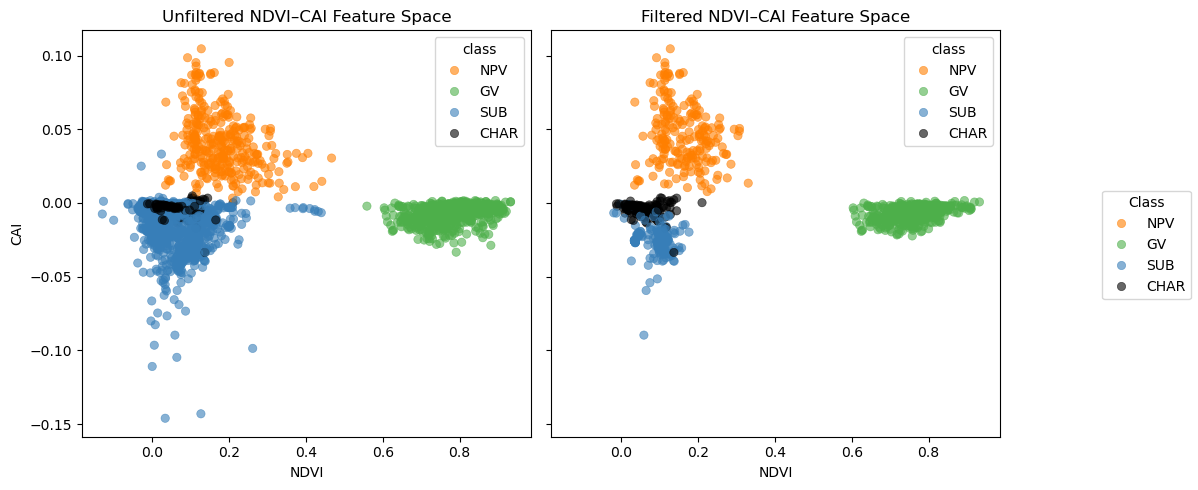

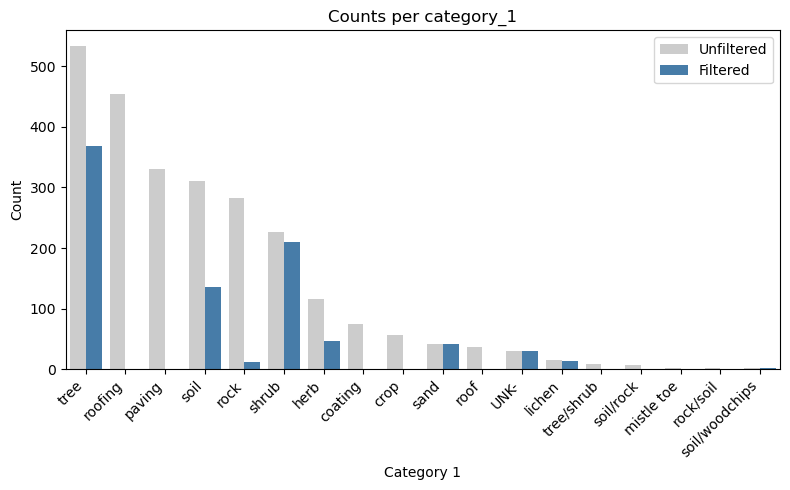

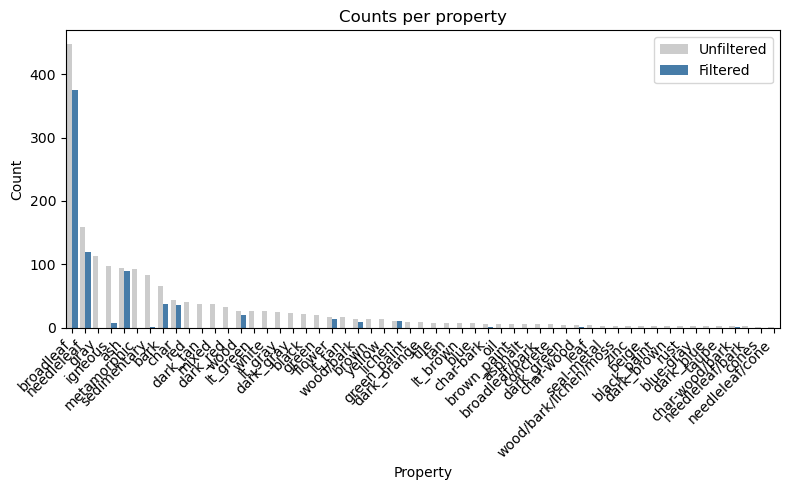

C:\Users\schnesha\AppData\Local\Temp\3\ipykernel_79448\4246341797.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


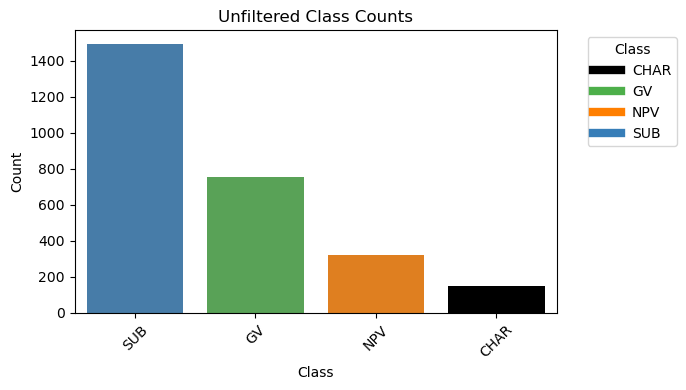

C:\Users\schnesha\AppData\Local\Temp\3\ipykernel_79448\4246341797.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


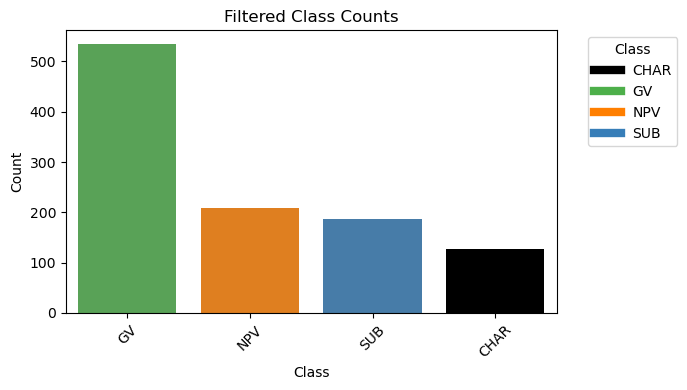

In [ ]:
# ------------------------------------------------------------
# Main execution
# ------------------------------------------------------------
if __name__ == "__main__":
    # Load data
    df = pd.read_csv(REFLECTANCE_FILE)
    BAND_MAP, numeric_cols = calc_ndvi_cai(df)

    # Compute NDVI/CAI
    df["NDVI"] = (df[BAND_MAP['800']] - df[BAND_MAP['670']]) / (df[BAND_MAP['800']] + df[BAND_MAP['670']])
    df["CAI"] = 0.5 * (df[BAND_MAP['2000']] + df[BAND_MAP['2200']]) - df[BAND_MAP['2100']]

    # Apply filters
    df_filtered = filter_endmembers(df.copy(), BAND_MAP, numeric_cols)

    df_filtered["NDVI"] = (df_filtered[BAND_MAP['800']] - df_filtered[BAND_MAP['670']]) / (df_filtered[BAND_MAP['800']] + df_filtered[BAND_MAP['670']])
    df_filtered["CAI"] = 0.5 * (df_filtered[BAND_MAP['2000']] + df_filtered[BAND_MAP['2200']]) - df_filtered[BAND_MAP['2100']]

    # Remove OTH before plotting
    df_plot = df[df[CLASS_COL] != "OTH"]
    df_filtered_plot = df_filtered[df_filtered[CLASS_COL] != "OTH"]

    # --------------------------------------------------------
    # Define color palette
    # --------------------------------------------------------
    # 🔹 Customize this palette as you wish — key: class label → color
    CLASS_PALETTE = {
        "GV": "#4daf4a",       # Green vegetation
        "NPV": "#ff7f00",      # Non-photosynthetic veg
        "SUB": "#377eb8",
       
        "CHAR": "#000000",
       
    }

    # Fallback color for any unmapped classes
    default_color = "#bbbbbb"

    # Ensure only existing classes are used
    existing_classes = sorted(df_plot[CLASS_COL].dropna().unique())
    plot_palette = {cls: CLASS_PALETTE.get(cls, default_color) for cls in existing_classes}

    # --------------------------------------------------------
    # 1. Spectra faceted by class (robust)
    # --------------------------------------------------------
 
    # --------------------------------------------------------
    # 2. NDVI–CAI scatter comparison (with legend & colors)
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    sns.scatterplot(
        ax=axes[0],
        data=df_plot,
        x="NDVI",
        y="CAI",
        hue=CLASS_COL,
        palette=plot_palette,
        alpha=0.6,
        edgecolor=None,
    )
    axes[0].set_title("Unfiltered NDVI–CAI Feature Space")

    sns.scatterplot(
        ax=axes[1],
        data=df_filtered_plot,
        x="NDVI",
        y="CAI",
        hue=CLASS_COL,
        palette=plot_palette,
        alpha=0.6,
        edgecolor=None,
    )
    axes[1].set_title("Filtered NDVI–CAI Feature Space")

    for ax in axes:
        ax.set_xlabel("NDVI")
        ax.set_ylabel("CAI")

    # Shared legend outside plots
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', title='Class')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

       # --------------------------------------------------------
    # 3. Summary bar charts (replacing print statements)
    # --------------------------------------------------------
    def plot_count_bars(df_unf, df_filt, col, title):
        """Plot unfiltered vs filtered counts as side-by-side bars."""
        counts_unf = df_unf[col].value_counts(dropna=False).rename("Unfiltered")
        counts_filt = df_filt[col].value_counts(dropna=False).rename("Filtered")
        counts_df = pd.concat([counts_unf, counts_filt], axis=1).fillna(0).astype(int).reset_index()
        counts_df = counts_df.rename(columns={"index": col})

        counts_df_melt = counts_df.melt(id_vars=col, var_name="Dataset", value_name="Count")

        plt.figure(figsize=(8, 5))
        sns.barplot(
            data=counts_df_melt,
            x=col,
            y="Count",
            hue="Dataset",
            palette={"Unfiltered": "#cccccc", "Filtered": "#377eb8"}
        )
        plt.title(title)
        plt.xticks(rotation=45, ha="right")
        plt.xlabel(col.replace("_", " ").capitalize())
        plt.ylabel("Count")
        plt.legend(title="")
        plt.tight_layout()
        plt.show()

    # ---- Plot counts per category_1 ----
    plot_count_bars(df, df_filtered, "category_1", "Counts per category_1")

    # ---- Plot counts per property ----
    plot_count_bars(df, df_filtered, "property", "Counts per property")


    # --------------------------------------------------------
    # 4. Bar charts for class counts (with palette & legend)
    # --------------------------------------------------------
    def plot_class_bar(df_in, title):
        plt.figure(figsize=(7, 4))
        sns.countplot(
            data=df_in,
            x=CLASS_COL,
            order=df_in[CLASS_COL].value_counts().index,
            palette=plot_palette
        )
        plt.title(title)
        plt.xticks(rotation=45)
        plt.xlabel("Class")
        plt.ylabel("Count")
        plt.legend(
            handles=[
                plt.Line2D([0], [0], color=color, lw=6, label=cls)
                for cls, color in plot_palette.items()
            ],
            title="Class",
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )
        plt.tight_layout()
        plt.show()

    plot_class_bar(df_plot, "Unfiltered Class Counts")
    plot_class_bar(df_filtered_plot, "Filtered Class Counts")


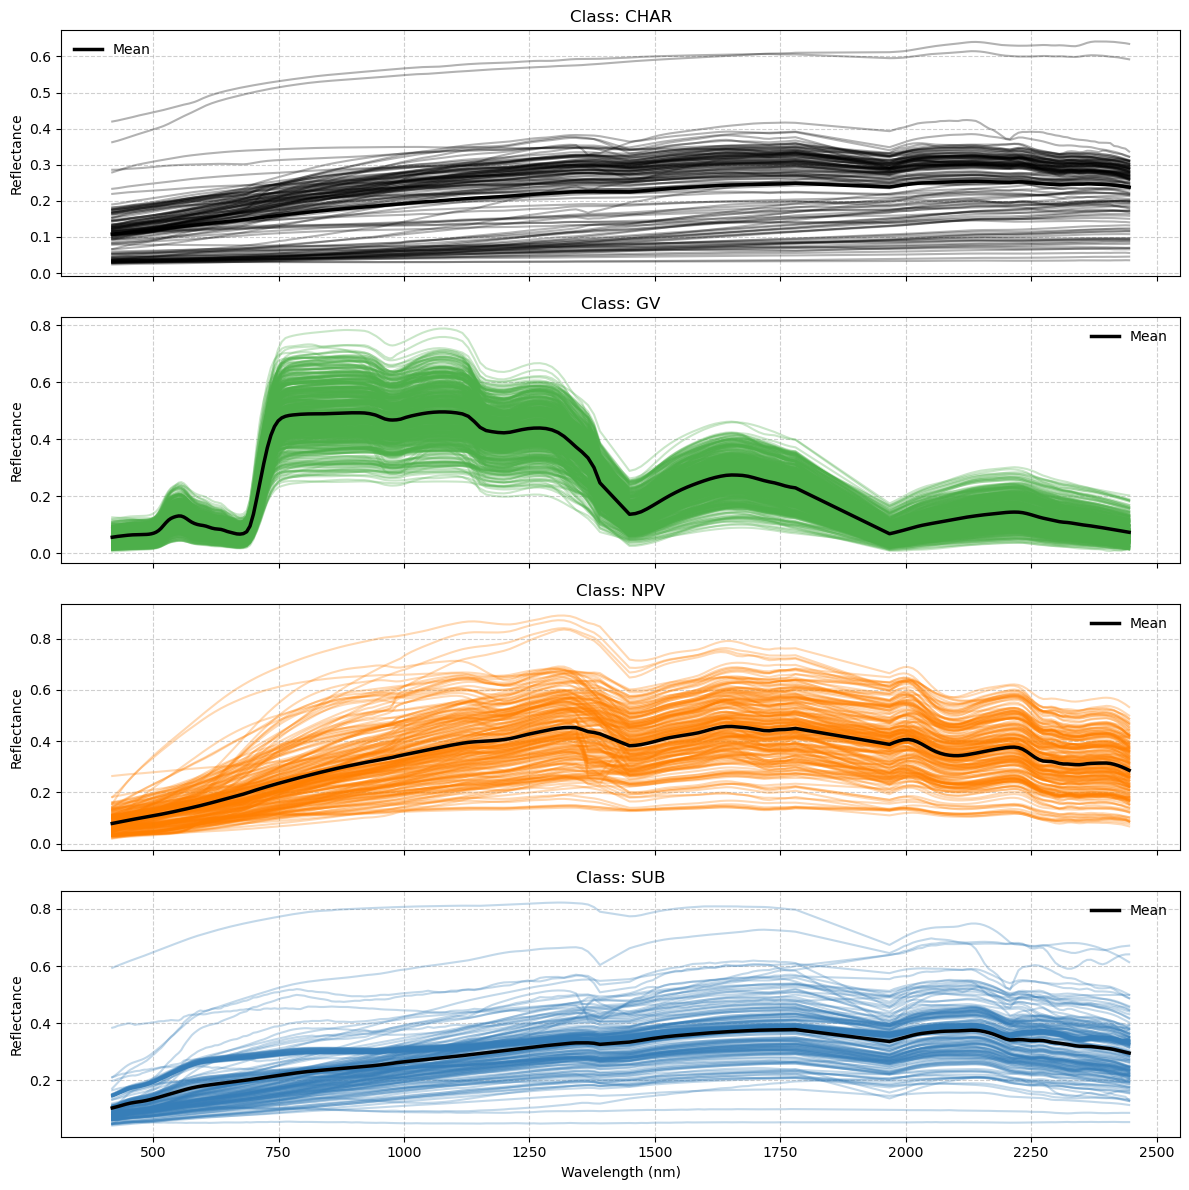

In [ ]:
import numpy as np


def plot_faceted_spectra_lib(df, numeric_cols, plot_palette, out_filename=None):
    import matplotlib.pyplot as plt

    wavelengths = np.array([float(w) for w in numeric_cols])
    classes = [cls for cls in plot_palette.keys() if cls in df['class'].unique()]
    n_classes = len(classes)

    fig, axes = plt.subplots(n_classes, 1, figsize=(12, 3 * n_classes), sharex=True)
    if n_classes == 1:
        axes = [axes]

    for ax, cls in zip(axes, classes):
        subset = df[df['class'] == cls]
        reflectances = subset[numeric_cols].values.astype(float)

        for spectrum in reflectances:
            ax.plot(wavelengths, spectrum, color=plot_palette.get(cls, 'gray'), alpha=0.3)

        mean_spectrum = np.mean(reflectances, axis=0)
        ax.plot(wavelengths, mean_spectrum, color="black", lw=2.5, label='Mean')

        ax.set_ylabel("Reflectance")
        ax.set_title(f"Class: {cls}")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(frameon=False)

    axes[-1].set_xlabel("Wavelength (nm)")
    plt.tight_layout()

    if out_filename:
        plt.savefig(out_filename, dpi=300, bbox_inches='tight')
        print(f"Faceted spectra plot saved to: {out_filename}")
    plt.show()

# Usage example:
plot_faceted_spectra_lib(df_filtered_plot, numeric_cols, plot_palette)
